In [ ]:
import urllib.request
import zipfile
import os

# NASA dataset link
url = "https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip"
save_path = "Battery_Data_Set.zip"

print("Downloading NASA Battery Dataset...")
urllib.request.urlretrieve(url, save_path)

print("Extracting files...")
with zipfile.ZipFile(save_path, 'r') as zip_ref:
    zip_ref.extractall("nasa_battery_data")

print("Download and extraction complete!")

Extracting files...
Download and extraction complete!


In [ ]:
# visualize data
import os 
import scipy.io # read matlab file tool
import numpy as np
import matplotlib.pyplot as plt

# figure style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [3]:
# 步驟 2：定義資料提取函數
def extract_battery_data(mat_path):
    # 1. 載入 .mat 檔案
    mat = scipy.io.loadmat(mat_path)
    b_name = os.path.splitext(os.path.basename(mat_path))[0] # 取得電池名字 (如 B0005)
    
    # 2. 深入 NASA 的巢狀結構取得所有循環數據
    cycles_data = mat[b_name][0, 0]['cycle'][0]
    
    discharge_capacities = []
    discharge_cycles = []
    voltage_curves = {} # 用來存特定圈數的電壓和溫度曲線
    
    d_count = 0
    for c in cycles_data:
        op_type = c['type'][0] # 取得操作類型 (charge / discharge / impedance)
        
        # 我們只要「放電 (discharge)」的數據！
        if op_type == 'discharge':
            d_count += 1
            data = c['data']
            
            # 提取當圈容量 (Capacity)
            if 'Capacity' in data.dtype.names and data['Capacity'][0, 0].size > 0:
                cap = data['Capacity'][0, 0][0, 0]
                discharge_capacities.append(cap)
                discharge_cycles.append(d_count)
            
            # 挑選第 1, 30, 60, 100, 130 圈，抓出詳細的 (時間, 電壓, 溫度) 曲線
            if d_count in [1, 30, 60, 100, 130]:
                t = data['Time'][0, 0].flatten()
                v = data['Voltage_measured'][0, 0].flatten()
                temp = data['Temperature_measured'][0, 0].flatten()
                voltage_curves[d_count] = (t, v, temp)
                
    return discharge_cycles, discharge_capacities, voltage_curves

print("解析函數建立完成！")

解析函數建立完成！


In [ ]:
# 步驟 3：讀取本地 dataset 資料夾裡的所有電池
dataset_dir = r"D:\Thesis\Battery_Data_Set\5. Battery Data Set\1. BatteryAgingARC-FY08Q4"
battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']

battery_results = {}
for b_id in battery_ids:
    mat_path = os.path.join(dataset_dir, f"{b_id}.mat")
    cycles, caps, v_curves = extract_battery_data(mat_path)
    
    battery_results[b_id] = {
        'cycles': np.array(cycles),
        'capacity': np.array(caps),
        'v_curves': v_curves
    }
    print(f"loaded {b_id}:  {len(caps)} cycle (initial capacity : {caps[0]:.3f} Ah -> end capacity: {caps[-1]:.3f} Ah)")


loaded B0005:  168 cycle (initial capacity : 1.856 Ah -> end capacity: 1.325 Ah)
loaded B0006:  168 cycle (initial capacity : 2.035 Ah -> end capacity: 1.186 Ah)
loaded B0007:  168 cycle (initial capacity : 1.891 Ah -> end capacity: 1.432 Ah)
loaded B0018:  132 cycle (initial capacity : 1.855 Ah -> end capacity: 1.341 Ah)


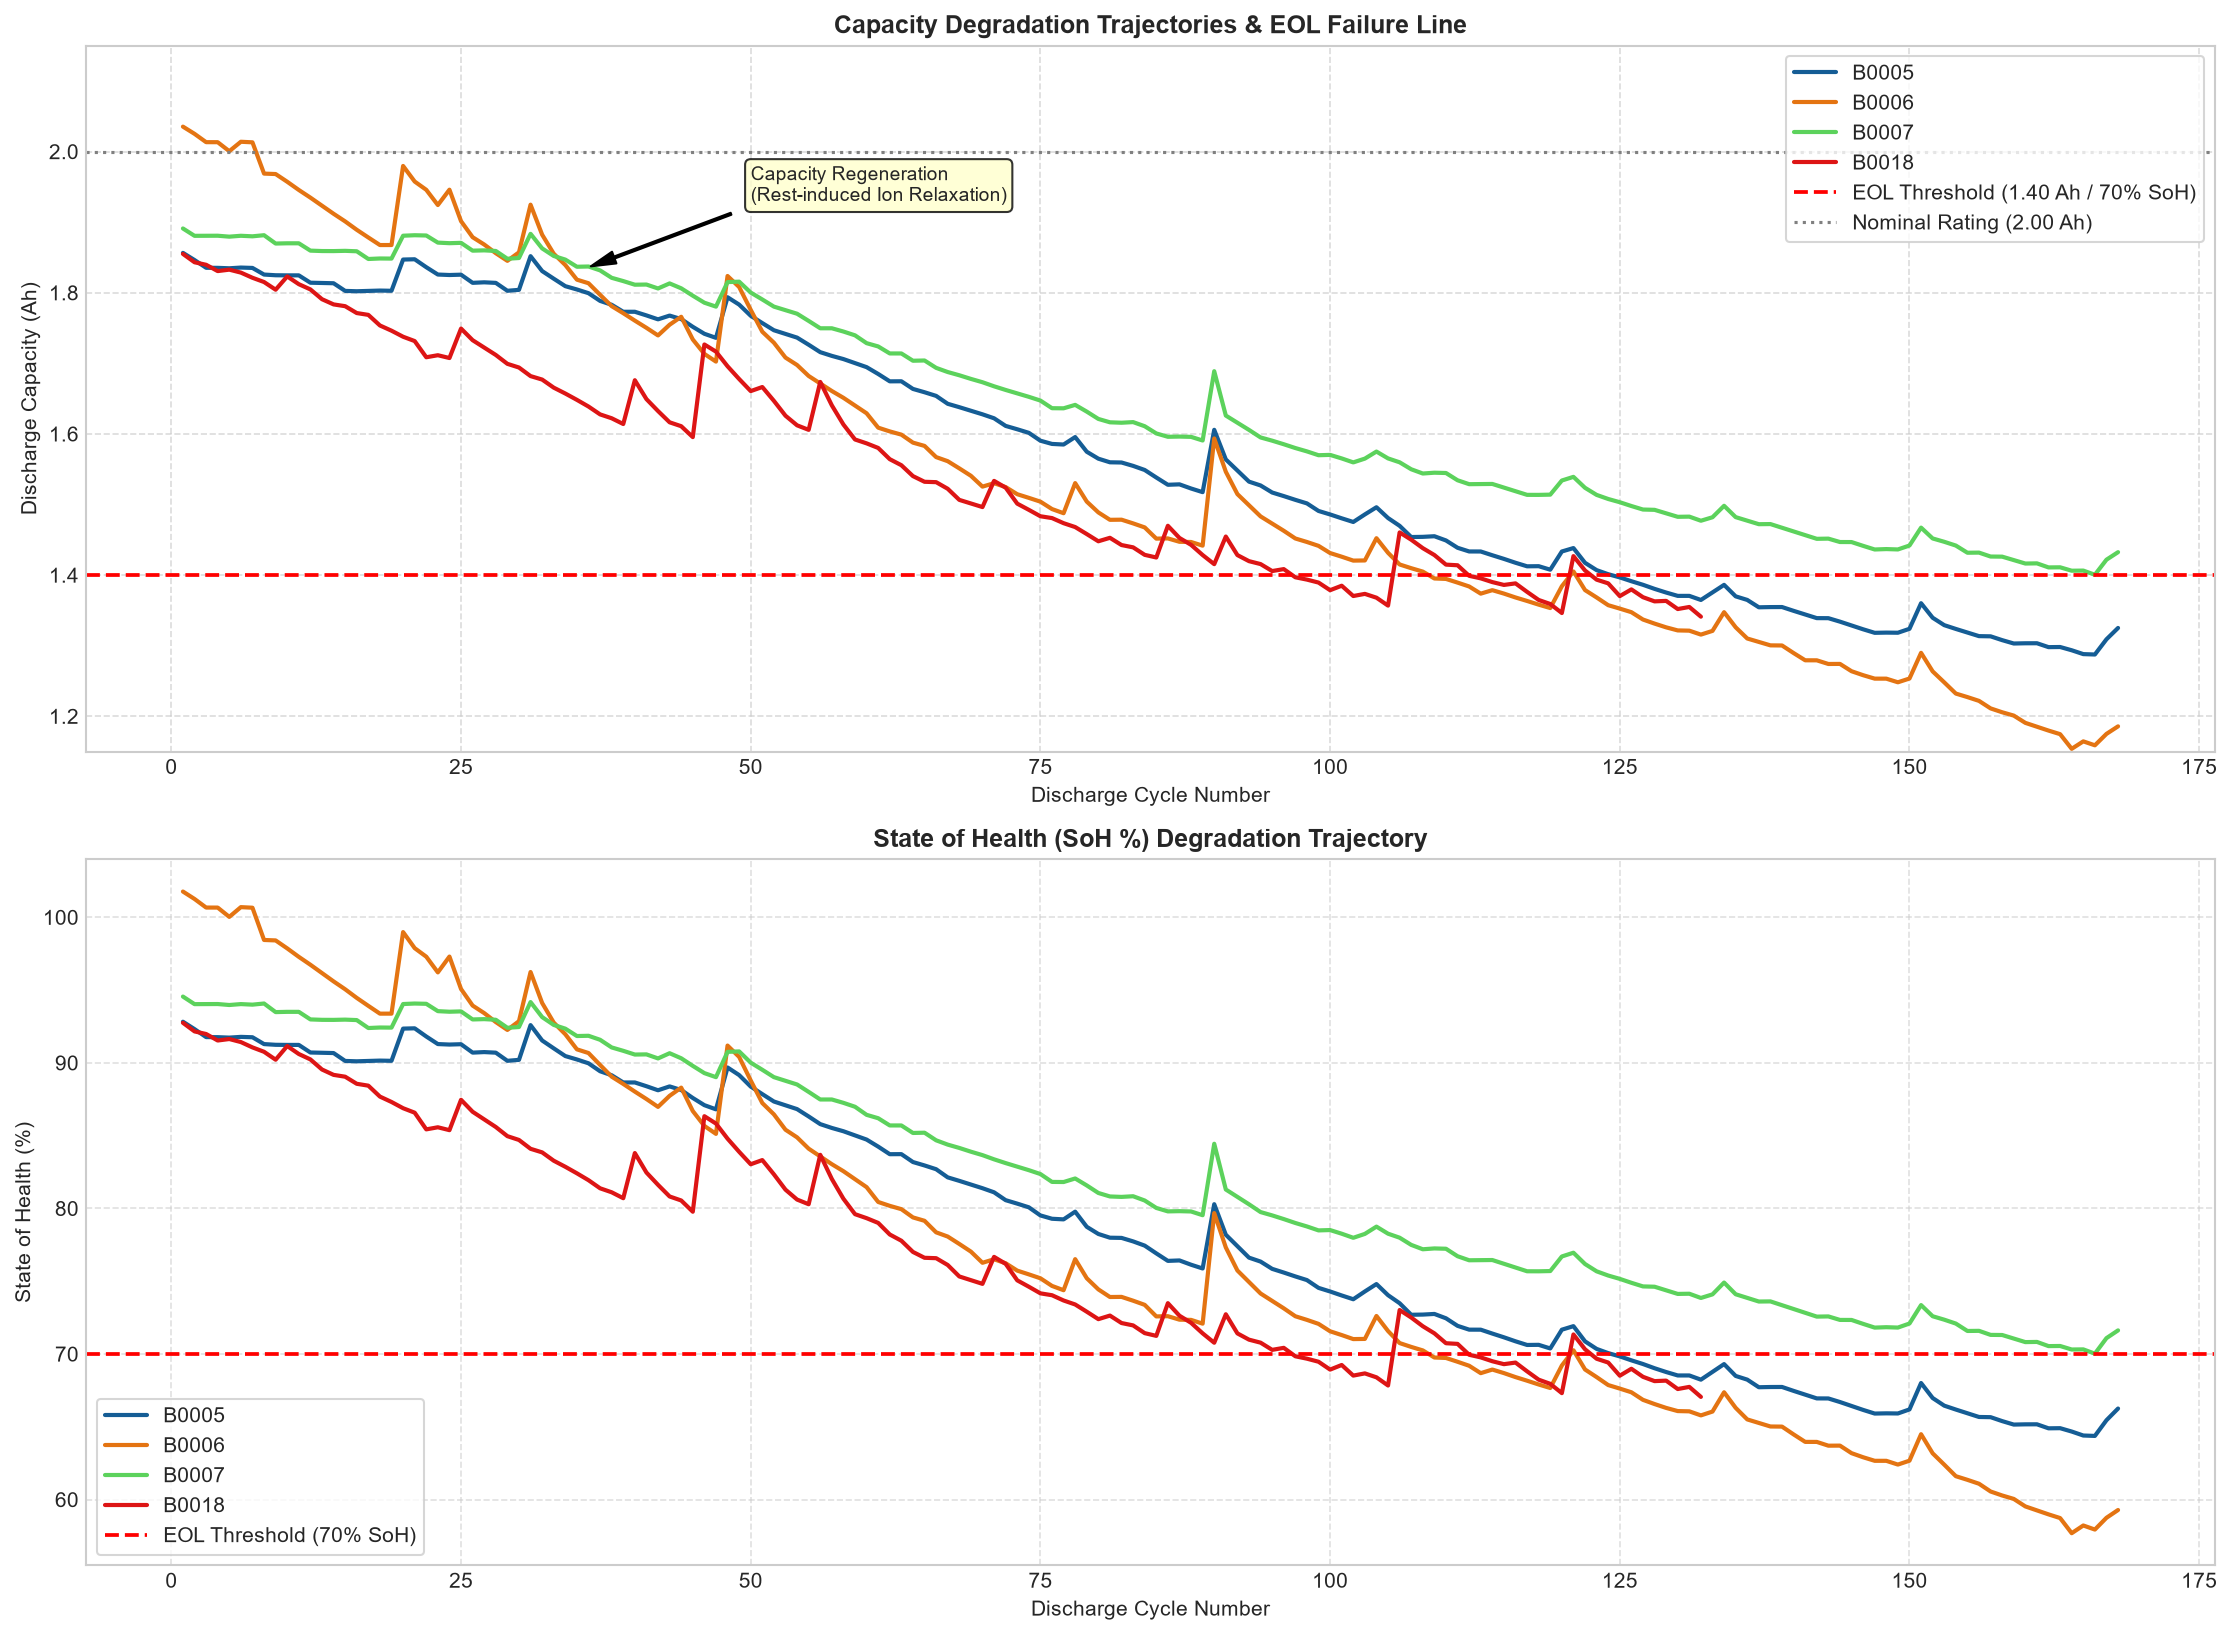

In [48]:
# =============================================================
# Step 4: Create 2x2 Publication-Grade Multi-Panel Visualization
# =============================================================
fig, axes = plt.subplots(2, 1, figsize=(15, 11), dpi=150)
colors = {'B0005': "#155d95", 'B0006': "#e47412", 'B0007': "#5cd25c", 'B0018': "#dd1515" }

# -------------------------------------------------------------
# (a) Top-Left: Capacity Degradation Curves & EOL Threshold
# -------------------------------------------------------------
ax1 = axes[0]
for b_id, res in battery_results.items():
    ax1.plot(res['cycles'], res['capacity'], label=b_id, color=colors[b_id], linewidth=2)

ax1.axhline(y=1.40, color='red', linestyle='--', linewidth=1.8, label='EOL Threshold (1.40 Ah / 70% SoH)')
ax1.axhline(y=2.00, color='gray', linestyle=':', label='Nominal Rating (2.00 Ah)')

# Capacity regeneration annotation (rest time)
ax1.annotate('Capacity Regeneration\n(Rest-induced Ion Relaxation)', 
             xy=(35, 1.83), xytext=(50, 1.93),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffffcc', alpha=0.8),
             fontsize=9)

ax1.set_title('Capacity Degradation Trajectories & EOL Failure Line', fontweight='bold', fontsize=12)
ax1.set_xlabel('Discharge Cycle Number')
ax1.set_ylabel('Discharge Capacity (Ah)')
ax1.set_ylim(1.15, 2.15)
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.7)

# -------------------------------------------------------------
# (b) Top-Right: State of Health (SoH %) Degradation Profile
# -------------------------------------------------------------
ax2 = axes[1]
for b_id, res in battery_results.items():
    soh = (res['capacity'] / 2.00) * 100.0
    ax2.plot(res['cycles'],res['capacity']/2*100, label=b_id, color=colors[b_id], linewidth=2)

ax2.axhline(y=70.0, color='red', linestyle='--', linewidth=1.8, label='EOL Threshold (70% SoH)')
ax2.set_title('State of Health (SoH %) Degradation Trajectory', fontweight='bold', fontsize=12)
ax2.set_xlabel('Discharge Cycle Number')
ax2.set_ylabel('State of Health (%)')
ax2.legend(loc='lower left', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

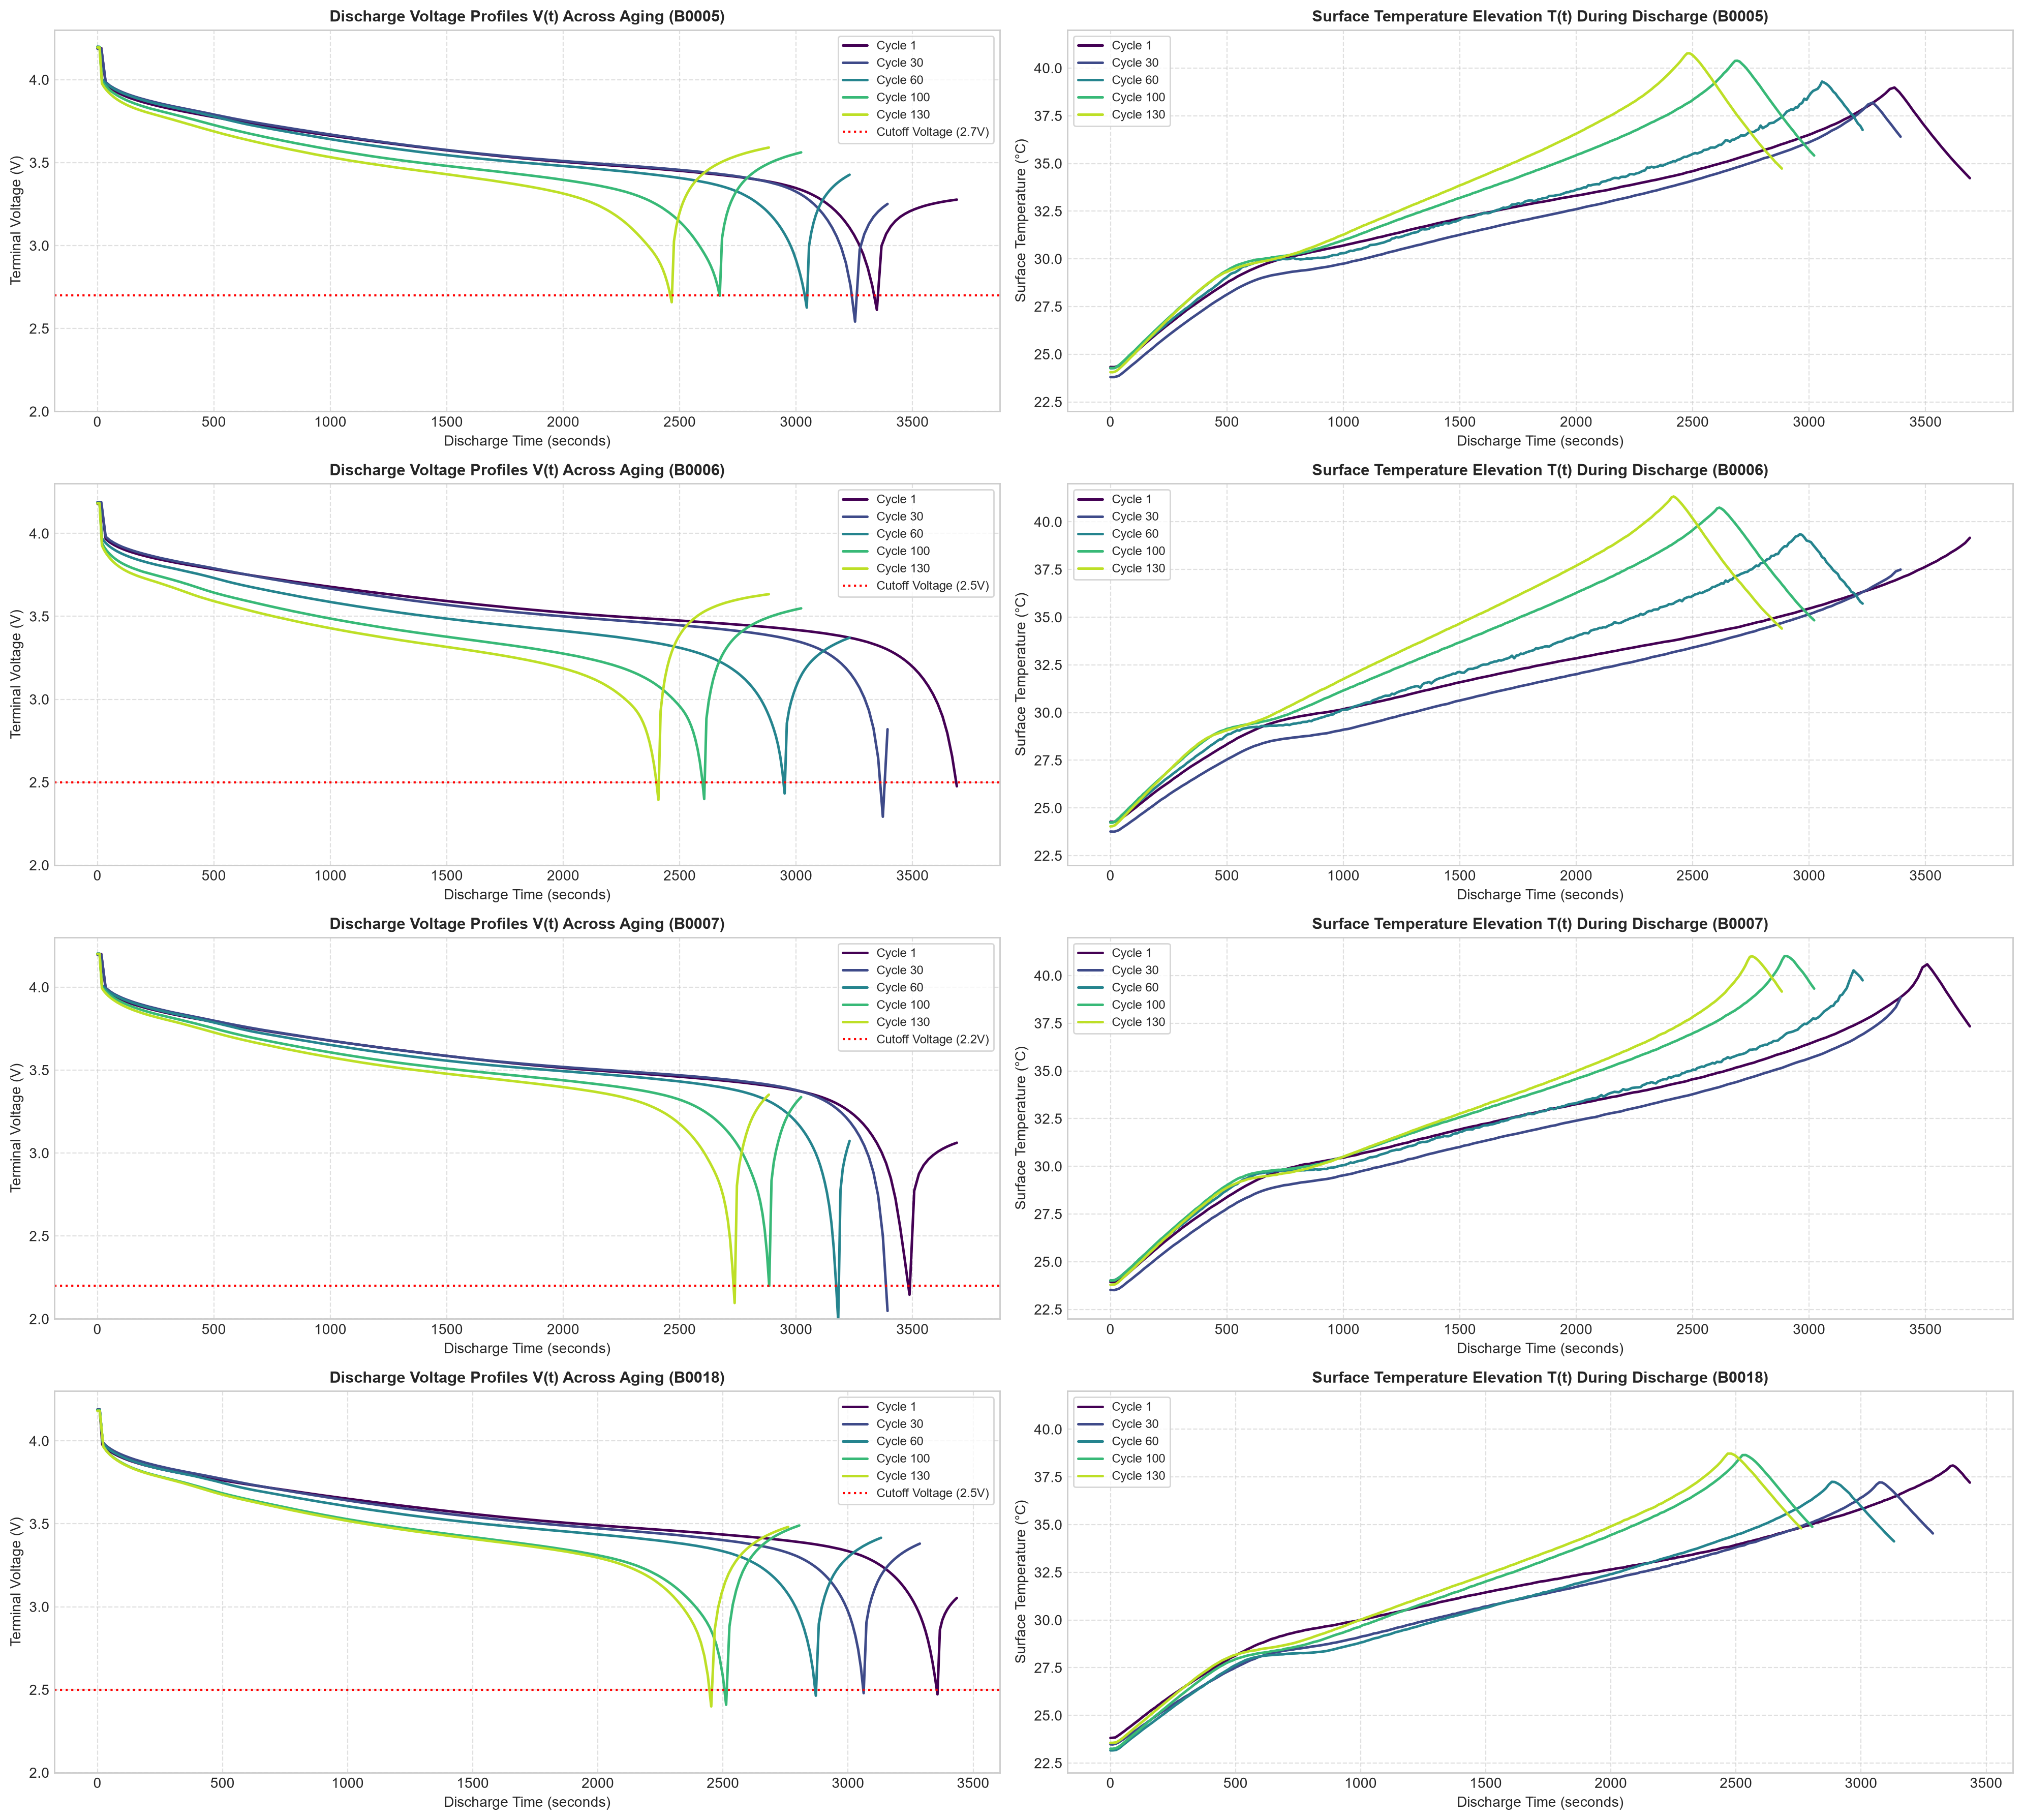

In [52]:
# =============================================================
# 4x2 Grid: Voltage and Temperature Profiles for B0005, B0006, B0007, B0018
# =============================================================
fig, axes = plt.subplots(4, 2, figsize=(20, 18), dpi=200)

# Define the 4 benchmark cells and their respective lower cutoff voltages
battery_list = ['B0005', 'B0006', 'B0007', 'B0018']
cutoff_voltages = {'B0005': 2.7, 'B0006': 2.5, 'B0007': 2.2, 'B0018': 2.5}

for row_idx, b_id in enumerate(battery_list):
    ax_v = axes[row_idx, 0]  # Left Column: Voltage Profile
    ax_t = axes[row_idx, 1]  # Right Column: Temperature Profile
    
    v_curves = battery_results[b_id]['v_curves']
    curve_colors = plt.cm.viridis(np.linspace(0, 0.9, len(v_curves)))
    cutoff_val = cutoff_voltages[b_id]
    
    # Plot waveforms for selected aging cycles (e.g. Cycle 1, 30, 60, 100, 130)
    for idx, (cyc, (t, v, temp)) in enumerate(sorted(v_curves.items())):
        # 1. Voltage curve
        ax_v.plot(t, v, label=f'Cycle {cyc}', color=curve_colors[idx], linewidth=1.8)
        # 2. Temperature curve
        ax_t.plot(t, temp, label=f'Cycle {cyc}', color=curve_colors[idx], linewidth=1.8)
    
    # --- Voltage Subplot Settings (Left) ---
    ax_v.axhline(y=cutoff_val, color='red', linestyle=':', label=f'Cutoff Voltage ({cutoff_val}V)')
    ax_v.set_title(f'Discharge Voltage Profiles V(t) Across Aging ({b_id})', fontweight='bold', fontsize=11)
    ax_v.set_xlabel('Discharge Time (seconds)')
    ax_v.set_ylabel('Terminal Voltage (V)')
    ax_v.set_ylim(2.0, 4.3)
    ax_v.legend(loc='upper right', frameon=True, fontsize=8.5)
    ax_v.grid(True, linestyle='--', alpha=0.6)
    
    # --- Temperature Subplot Settings (Right) ---
    ax_t.set_title(f'Surface Temperature Elevation T(t) During Discharge ({b_id})', fontweight='bold', fontsize=11)
    ax_t.set_xlabel('Discharge Time (seconds)')
    ax_t.set_ylabel('Surface Temperature (°C)')
    ax_t.set_ylim(22, 42)
    ax_t.legend(loc='upper left', frameon=True, fontsize=8.5)
    ax_t.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [14]:
import scipy.io as sio

mat = sio.loadmat(r"D:\Thesis\Battery_Data_Set\5. Battery Data Set\1. BatteryAgingARC-FY08Q4\B0005.mat")
cycles = mat['B0005'][0, 0]['cycle']

# 找第一個放電循環 (discharge)
for i in range(cycles.shape[1]):
    c = cycles[0, i]
    if c['type'][0] == 'discharge':
        print("找到第 1 次放電測試：")
        print("環境溫度:", c['ambient_temperature'][0, 0], "°C")
        print("開始時間:", c['time'][0])
        
        # 取得 data 內部的數值
        data = c['data'][0, 0]
        capacity = data['Capacity'][0, 0]
        voltages = data['Voltage_measured'].flatten()  # 轉成 1D array
        currents = data['Current_measured'].flatten()
        times = data['Time'].flatten()
        
        print(f"測得容量: {capacity:.4f} Ah")
        print(f"採樣點數: {len(times)} 點")
        print(f"放電時長: {times[-1]:.1f} 秒")
        print(f"電壓範圍: {voltages.max():.2f}V -> {voltages.min():.2f}V")
        break

找到第 1 次放電測試：
環境溫度: 24 °C
開始時間: [2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2.5000e+01 4.1593e+01]
測得容量: 1.8565 Ah
採樣點數: 197 點
放電時長: 3690.2 秒
電壓範圍: 4.19V -> 2.61V
